In [4]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# notebook は EXP_v4/src/ にあるので parents[1] がプロジェクトルート
ROOT = Path().resolve().parents[1]
RESULTS_DIR = ROOT / "EXP_v4" / "results"
print(f"Project root: {ROOT}")
print(f"Results dir : {RESULTS_DIR}")

Project root: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History
Results dir : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v4/results


In [5]:
dqn_path = RESULTS_DIR / "summary_uncor_1_100items_DQN_normal_epsilon_0.1_gamma_0.7_research_param.csv"
mfi_path = RESULTS_DIR / "summary_uncor_1_100items_MFI_MLE_python.csv"

dqn = pd.read_csv(dqn_path)
mfi = pd.read_csv(mfi_path)

print(f"DQN: {dqn_path.name}")
display(dqn)
print(f"MFI: {mfi_path.name}")
display(mfi)

DQN: summary_uncor_1_100items_DQN_normal_epsilon_0.1_gamma_0.7_research_param.csv


,step,Bias,RMSE,MAE
0,1.0,0.453501,1.186681,0.947272
1,2.0,0.342903,1.100191,0.863309
2,3.0,0.221180,1.083762,0.853468
3,4.0,0.035021,1.185007,0.862482
4,5.0,0.067132,0.997979,0.743779
5,6.0,0.071915,0.909172,0.687419
6,7.0,0.066447,0.827819,0.631808
7,8.0,0.057522,0.779070,0.597654
8,9.0,0.028949,0.738725,0.563431
9,10.0,0.021461,0.723136,0.544181


MFI: summary_uncor_1_100items_MFI_MLE_python.csv


,step,Bias,RMSE,MAE,r
0,1,0.461654,1.169435,0.938701,0.474093
1,2,0.315874,1.100315,0.866605,0.570919
2,3,0.180710,1.015445,0.793002,0.641252
3,4,0.068033,1.127858,0.826751,0.654936
4,5,0.121668,0.921814,0.694680,0.717821
5,6,0.086166,0.875384,0.656448,0.745183
6,7,0.079705,0.820413,0.613250,0.772877
7,8,0.061950,0.774378,0.580295,0.792777
8,9,0.052574,0.728220,0.544800,0.812053
9,10,0.047590,0.677102,0.510861,0.832728


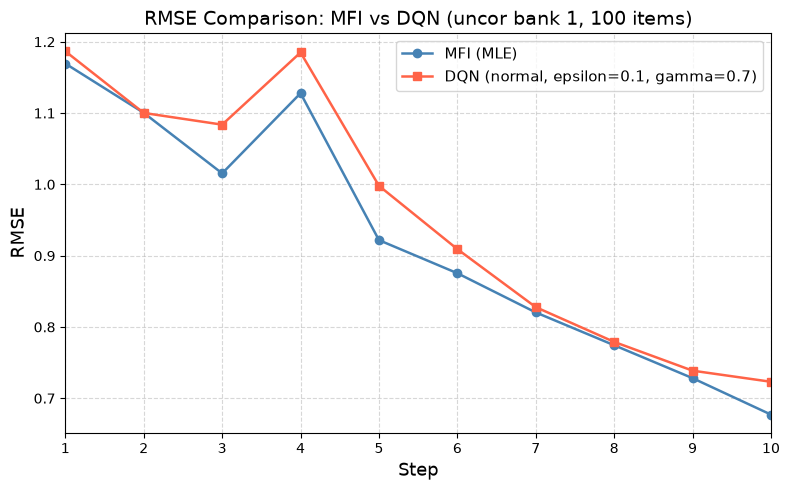

Saved to /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v4/results/rmse_comparison_uncor_1_100items_DQN_research_param_vs_MFI.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(mfi["step"], mfi["RMSE"], label="MFI (MLE)", color="steelblue", linewidth=1.8, marker="o")
ax.plot(dqn["step"], dqn["RMSE"], label="DQN (normal, epsilon=0.1, gamma=0.7)", color="tomato", linewidth=1.8, marker="s")

ax.set_xlabel("Step", fontsize=13)
ax.set_ylabel("RMSE", fontsize=13)
ax.set_title("RMSE Comparison: MFI vs DQN (uncor bank 1, 100 items)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(1, max(dqn["step"].max(), mfi["step"].max()))

plt.tight_layout()

out_path = RESULTS_DIR / "rmse_comparison_uncor_1_100items_DQN_research_param_vs_MFI.png"
fig.savefig(out_path, dpi=150)
plt.show()
print(f"Saved to {out_path}")